# 1. Setup & Environment
- 포스터 도표 및 차트 렌더링 라이브러리(Matplotlib, Pandas) 로드
- 한글 폰트(NanumGothic) 및 유니코드 마이너스 부호 환경 구성

In [1]:
# 1. 라이브러리 로드 및 시각화 환경 설정
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

# 폰트 및 유니코드 설정
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# 2. Configuration & Color Theme Definitions
- 급증 요인 분해 산출물 및 이미지 저장 경로(`output/maps`) 설정
- 포스터 미니맵과 통일된 학술 시각화 테마 및 판정 유형별 컬러 팔레트 정의

In [2]:
# 2. 경로 및 시각화 스타일 정의
BASE_DIR = Path("/mnt/cowork/EV")
SPIKE_FP_MW = BASE_DIR / "output/spike_cause_decomposition_2021_2022_mw.csv"
SPIKE_FP_ORIG = BASE_DIR / "output/spike_cause_decomposition_2021_2022.csv"

DIR_MAPS = BASE_DIR / "output/maps"
DIR_MAPS.mkdir(parents=True, exist_ok=True)
OUT_PNG_MW = DIR_MAPS / "poster_spike_cause_summary_mw.png"

# 학술 포스터 전용 테마 팔레트
CHART_THEME = {
    "SUPPLY": "#d73027",      # 신규 공급형 (Crimson Red)
    "MIXED": "#33586b",       # 공급+도로망 복합형 (Slate Blue)
    "ZERO": "#d8d2c2",        # 빈도 0건 항목 (Muted Sand/Gray)
    "TEXT": "#222222",        # 주 텍스트
    "MUTED": "#666666",       # 보조 텍스트 및 캡션
    "TBL_HEADER": "#f2ede1",  # 테이블 헤더 배경
    "TBL_BORDER": "#e5ddc9"   # 테이블 셀 테두리선
}

# 판정 유형별 시각화 매핑
VERDICT_CONFIG = {
    "신규 공급형": {"label": "신규공급", "color": CHART_THEME["SUPPLY"]},
    "공급+도로망 복합": {"label": "복합", "color": CHART_THEME["MIXED"]},
    "도로망 단독": {"label": "도로망", "color": CHART_THEME["ZERO"]},
    "계산 이상치(600초 초과 급변)": {"label": "이상치", "color": CHART_THEME["ZERO"]}
}

CATEGORIES = ["신규 공급형", "공급+도로망 복합", "도로망 단독", "계산 이상치(600초 초과 급변)"]

print(f">> 출력 대상 파일명: {OUT_PNG_MW.name}")

>> 출력 대상 파일명: poster_spike_cause_summary_mw.png


# 3. Data Loader & Decomposition Preprocessing
- 2021→2022 급증 요인 분해 결과 CSV(`_mw.csv` 우선) 로드
- 접근성 변화폭($\Delta 2SFCA$) 기준 내림차순 정렬 및 상위 10개 동 추출

In [3]:
# 3. 데이터 로드 및 전처리
fp_in = SPIKE_FP_MW if SPIKE_FP_MW.exists() else SPIKE_FP_ORIG
if not fp_in.exists():
    raise FileNotFoundError(f"급증 원인 분해 CSV 파일이 누락되었습니다: {fp_in}")

df_spike = pd.read_csv(fp_in)
df_spike = df_spike.sort_values("delta_score", ascending=False).reset_index(drop=True)
df_spike["rank"] = df_spike.index + 1
df_top10 = df_spike.head(10).copy()

# 판정 유형별 빈도 집계 (0건 항목 포함)
counts = df_top10["verdict"].value_counts()
cat_values = [counts.get(c, 0) for c in CATEGORIES]
cat_colors = [
    CHART_THEME["SUPPLY"] if c == "신규 공급형" else (
        CHART_THEME["MIXED"] if c == "공급+도로망 복합" else CHART_THEME["ZERO"]
    ) for c in CATEGORIES
]

print(f">> 데이터 로드 완료: {fp_in.name} (상위 {len(df_top10)}개 행정동 분석)")
for cat, val in zip(CATEGORIES, cat_values):
    print(f"   - {cat:<24}: {val}개 동")

>> 데이터 로드 완료: spike_cause_decomposition_2021_2022.csv (상위 10개 행정동 분석)
   - 신규 공급형                  : 8개 동
   - 공급+도로망 복합               : 2개 동
   - 도로망 단독                  : 0개 동
   - 계산 이상치(600초 초과 급변)      : 0개 동


# 4. Dual-Panel Figure Rendering (Bar Chart + Styled Summary Table)
- 좌측: 4대 판정 유형별 행정동 빈도 수평 막대 차트 (0건 명시)
- 우측: 상위 10개 급증 행정동 상세 테이블 (자치구·동, 신규충전소, 판정 태그)
- 하단 분석 근거 메타데이터 캡션 배치 및 고해상도(300 DPI) 이미지 내보내기

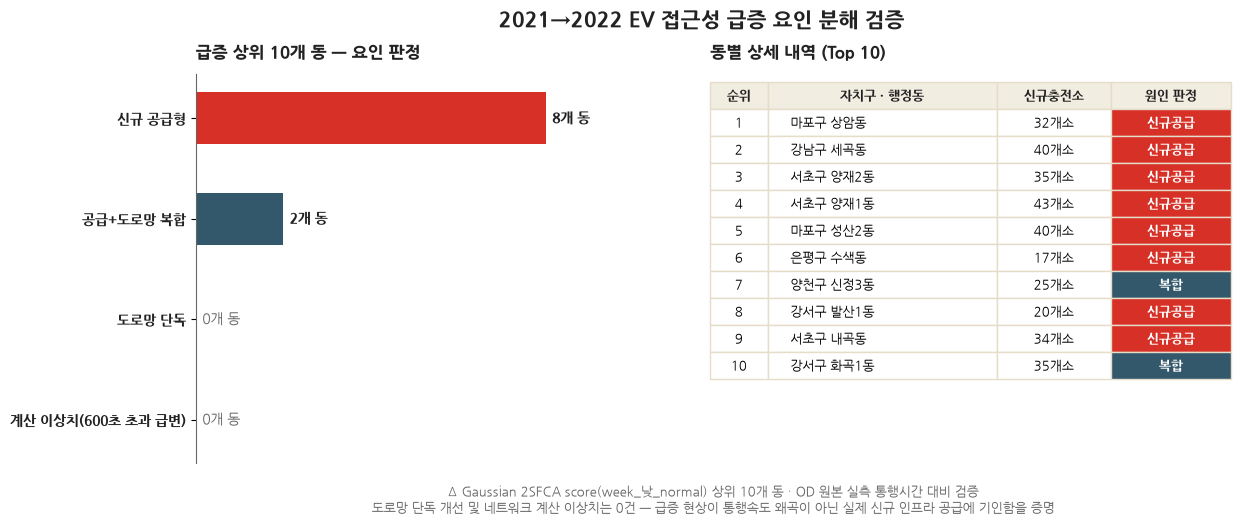

>> 포스터 Figure 5 고해상도 이미지 저장 완료: /mnt/cowork/EV/output/maps/poster_spike_cause_summary_mw.png


In [4]:
# 4. 결합 피겨 렌더링 및 내보내기
fig = plt.figure(figsize=(11.5, 5.4), facecolor="white")
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.4], wspace=0.32, top=0.84, bottom=0.12, left=0.06, right=0.96)

ax_bar = fig.add_subplot(gs[0])
ax_tbl = fig.add_subplot(gs[1])

# --- [좌측: 판정 유형별 수평 막대] ---
y_pos = range(len(CATEGORIES))
bars = ax_bar.barh(y_pos, cat_values, color=cat_colors, height=0.52, edgecolor="none")
ax_bar.set_yticks(list(y_pos))
ax_bar.set_yticklabels(CATEGORIES, fontsize=10, color=CHART_THEME["TEXT"], fontweight="bold")
ax_bar.invert_yaxis()

for yi, v in zip(y_pos, cat_values):
    txt_color = CHART_THEME["TEXT"] if v > 0 else CHART_THEME["MUTED"]
    weight = "bold" if v > 0 else "normal"
    ax_bar.text(v + 0.15, yi, f"{v}개 동", va="center", fontsize=10, color=txt_color, fontweight=weight)

ax_bar.set_xlim(0, 8.5)
ax_bar.set_xticks([])
for spine in ["top", "right", "bottom"]:
    ax_bar.spines[spine].set_visible(False)
ax_bar.spines["left"].set_color(CHART_THEME["MUTED"])
ax_bar.set_title("급증 상위 10개 동 — 요인 판정", fontsize=12.5, fontweight="bold", color=CHART_THEME["TEXT"], pad=12, loc="left")

# --- [우측: 상위 10개 동 상세 테이블] ---
ax_tbl.axis("off")
ax_tbl.set_title("동별 상세 내역 (Top 10)", fontsize=12.5, fontweight="bold", color=CHART_THEME["TEXT"], pad=12, loc="left")

col_labels = ["순위", "자치구 · 행정동", "신규충전소", "원인 판정"]
cell_text = []
cell_colors = []

for _, r in df_top10.iterrows():
    verdict = r["verdict"]
    v_label = VERDICT_CONFIG[verdict]["label"]
    v_color = VERDICT_CONFIG[verdict]["color"]
    
    cell_text.append([str(r["rank"]), f"{r['gu']} {r['dong']}", f"{int(r['n_new_stations'])}개소", v_label])
    cell_colors.append(["white", "white", "white", v_color])

tbl = ax_tbl.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellColours=cell_colors,
    colLoc="center",
    cellLoc="center",
    loc="upper center",
    colWidths=[0.11, 0.44, 0.22, 0.23]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.62)

# 테이블 셀 서식 조정
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(CHART_THEME["TBL_BORDER"])
    if row == 0:
        cell.set_facecolor(CHART_THEME["TBL_HEADER"])
        cell.set_text_props(fontweight="bold", color=CHART_THEME["TEXT"])
    elif col == 3:
        cell.set_text_props(color="white", fontweight="bold")
    elif col == 1:
        cell.set_text_props(ha="left")

# 헤더 및 학술 캡션
fig.suptitle("2021→2022 EV 접근성 급증 요인 분해 검증", fontsize=15, fontweight="bold", color=CHART_THEME["TEXT"], y=0.96)
fig.text(
    0.51, 0.03,
    "Δ Gaussian 2SFCA score(week_낮_normal) 상위 10개 동 · OD 원본 실측 통행시간 대비 검증\n"
    "도로망 단독 개선 및 네트워크 계산 이상치는 0건 — 급증 현상이 통행속도 왜곡이 아닌 실제 신규 인프라 공급에 기인함을 증명",
    ha="center", fontsize=9, color=CHART_THEME["MUTED"], linespacing=1.3
)

# 300 DPI 저장 및 출력
fig.savefig(OUT_PNG_MW, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f">> 포스터 Figure 5 고해상도 이미지 저장 완료: {OUT_PNG_MW}")

# 5. Output Verification
- 생성된 300 DPI 고해상도 요약 차트 이미지 파일의 경로 및 파일 크기(MB) 무결성 검증

In [5]:
# 5. 산출물 파일 상태 확인
if OUT_PNG_MW.exists():
    file_size_mb = OUT_PNG_MW.stat().st_size / (1024 * 1024)
    print("=" * 70)
    print(f"  파일명    : {OUT_PNG_MW.name}")
    print(f"  절대 경로 : {OUT_PNG_MW.resolve()}")
    print(f"  파일 크기 : {file_size_mb:.2f} MB")
    print("  상태      : 정상 저장 완료 (포스터 Figure 5 배치 규격 충족)")
    print("=" * 70)
else:
    print(f"[!] 파일 저장 실패: {OUT_PNG_MW}")

  파일명    : poster_spike_cause_summary_mw.png
  절대 경로 : /mnt/cowork/EV/output/maps/poster_spike_cause_summary_mw.png
  파일 크기 : 0.26 MB
  상태      : 정상 저장 완료 (포스터 Figure 5 배치 규격 충족)
